# **3 Question Formulation**

## **3.5 Research Question: The Immigrant Advantage?**

**The Question**

* **"Does national origin significantly determine income potential in the 1994 US census? Specifically, if we move beyond geographical boundaries and group countries based on economic performance, can we identify a 'High-Success' immigrant class that statistically outperforms US-natives?"**

* *Note:* This question investigates whether the common assumption—that immigrants face economic disadvantages relative to natives—holds true for all groups, or if specific migration patterns (like "Brain Drain") create elite economic cohorts.

**Motivation & Benefits**

* *Why is this question worth investigating?*
    * **High Cardinality Noise:** The `native-country` feature has over 40 unique values. Using standard One-Hot Encoding creates sparse vectors that may confuse the model.
    * **Hidden Patterns:** A simple "US vs. Non-US" split might mask the fact that immigrants from certain countries (e.g., India, Taiwan, France) often migrate as highly skilled professionals.

* *Who would care about the answer?*
    * **Policy Makers:** To understand how different migration streams (skilled vs. unskilled) integrate economically.
    * **Recruiters & Companies:** To identify regions producing high-performing talent pools.

* *What real-world problem does this inform?*
    * **Feature Selection Strategy:** If we prove that "Economic Grouping" is statistically significant, we can replace 40+ country features with a single, powerful `origin_group` variable, improving model efficiency without losing information.

### **Methodology**

To objectively address this question, we employ a **Data-Driven Grouping Strategy** combined with **Statistical Validation**:

1.  **Data Preparation (Target & Imputation):**
    * Convert `income` to binary (0/1).
    * Impute missing `native-country` values as "Unknown" to preserve sample size.

2.  **Dynamic Grouping Logic (The Core Strategy):**
    Instead of manual grouping (e.g., by continent), we group by **observed performance**:
    * **Calculate Success Rate:** $\frac{\text{Count >50K}}{\text{Total Count}}$ for each country.
    * **Define Threshold:** Use the **Global Average Success Rate** of the entire dataset as the benchmark.
    * **Classification:**
        * **High-Success Immigrant:** Countries with Success Rate > Global Average.
        * **Low-Success Immigrant:** Countries with Success Rate <= Global Average.
        * **US-Native:** Kept separate as the baseline.

3.  **Statistical Validation:**
    * Use a **Chi-square Test of Independence** to confirm if the income differences between these new groups are statistically significant ($p < 0.05$).

4.  **Evaluation Metric:**
    * We analyze the **Success Rate (%)** of each group to confirm if the "High-Success" group effectively separates wealthy individuals from the rest.

### **Data-Driven Feature Engineering for `native-country`**

To analyze the impact of national origin on income, we apply a **Data-Driven Feature Engineering** workflow.  
The variable `native-country` has **high cardinality** (>40 unique values), which increases noise and reduces model interpretability.  
Therefore, we group countries based on their **actual economic performance within the dataset**.

### **Workflow Overview**

#### **1. Data Import**
Load the Adult Census dataset with configurations to handle common data issues:
- **`header=0`**: Uses the first row as column names.  
- **`na_values=["?"]`**: Treats "?" as missing values.
- **`skipinitialspace=True`**: Removes leading spaces after delimiters.

**Outcome:** Dataset columns are correctly recognized, missing values are standardized, and data is ready for analysis.


#### **2. Data Preparation & Dynamic Grouping Execution**
This step performs three key operations:

**2.1. Target Construction**
- Convert the `income` variable into binary format (`income_binary`):
  - `1` → income >50K  
  - `0` → income ≤50K
- Fill missing values in `native.country` with `"Unknown"` to preserve sample size.

**2.2. Data-Driven Mapping Strategy**
- **Step A:** Calculate success rates and sample sizes for each country.
- **Step B:** Determine the **Global Success Rate Threshold** (overall dataset average).
- **Step C:** Filter high-performing countries (success rate > global threshold, excluding United-States).

**2.3. Dynamic Origin Assignment**
- Apply the grouping logic to create the `origin_group` feature using the identified high-success countries.
- Validate the distribution of the new groups.


#### **3. Statistical Analysis & Hypothesis Testing**
Validate that the created groups are statistically meaningful:

**3.1. Group-Level Performance Statistics**
- Calculate success rate (%) and sample size for each `origin_group`.
- Sort by success rate to identify top-performing groups.

**3.2. Statistical Significance Test (Chi-square)**
- Conduct **Chi-square test of independence** to evaluate whether income distribution differs significantly across origin groups.
- **Null Hypothesis (H₀):** Income level is independent of origin group.
- **Alternative (H₁):** Income level depends on origin group.

**Outcome:** Display summary table and p-value to confirm statistical significance.


#### **4. Visualization**
Provide visual validation of the grouping strategy:

**4.1. Origin Group Performance**
- Bar chart showing success rate by `origin_group` with global threshold reference line.
- Percentage labels for clear interpretation.

**4.2. Top-Performing Countries**
- Horizontal bar chart displaying Top 10 countries with highest income rates (among countries with sufficient sample size).
- Global threshold line for comparison.

**Purpose:** Confirm effectiveness of dynamic grouping and reveal cross-regional income disparities.

### **3.5.1 Data import**
This step loads the Adult Census dataset with settings designed to catch and fix common errors immediately. By handling placeholders and extra spaces during the import, we ensure the data is clean, consistent, and ready for analysis right from the start.

#### Loading Configuration
- **`header=0`** ensures the first row is used as column names.  
- **`na_values=['?']`** converts placeholder missing values into `NaN`.  
- **`skipinitialspace=True`** removes leading spaces after delimiters to avoid category inconsistencies.

#### Outcome
- Dataset columns are correctly recognized.  
- Missing values are standardized.  
- The dataset shape and preview (first 5 rows) confirm a successful loading step.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# Setting up visualization preferences
sns.set_style("whitegrid")
%matplotlib inline

In [2]:
#Read file
# header=0 to use the first row as column names
# na_values=['?'] to treat '?' as NaN
# skipinitialspace=True to ignore spaces after delimiters
df = pd.read_csv('../data/adult.csv', header=0, na_values=['?'], skipinitialspace=True)

print("Data loaded successfully. Names of columns:")
display(df.columns.tolist())

print("Size of the dataset:")
display(df.shape)
print("First 5 rows of the dataset:")
display(df.head())

Data loaded successfully. Names of columns:


['age',
 'workclass',
 'fnlwgt',
 'education',
 'education.num',
 'marital.status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'capital.gain',
 'capital.loss',
 'hours.per.week',
 'native.country',
 'income']

Size of the dataset:


(32561, 15)

First 5 rows of the dataset:


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


### **3.5.2 Data Preparation & Dynamic Grouping Execution**
In this step, we translate raw data into clear analytical targets. First, we convert the text-based income labels into a binary format (0 or 1) to enable mathematical calculation. Second, we move beyond traditional geographical grouping (like continents) and instead use a **data-driven approach**. By calculating the actual economic success rates of immigrants from each nation, we objectively classify countries into performance-based groups. This allows us to uncover **"High-Success"** cohorts that might be missed by standard regional categories.

#### **Overview of Execution Steps**
To implement the logic above, the following code block will perform these specific actions:

1.  **Binary Encoding:** Create `income_binary` by mapping `>50K` to `1` and `<=50K` to `0`.
2.  **Handle Missing Data:** Fill gaps in `native.country` with `"Unknown"`.
3.  **Compute Metrics:** Calculate the success rate for each country and determine the global average.
4.  **Define Groups:** Identify which countries belong to the "High-Success" list based on the global benchmark.
5.  **Feature Creation:** Apply the grouping logic to create the new `origin_group` column (US-Native vs. High-Success vs. Low-Success).
6.  **Validation:** Print the value counts to verify the distribution of the new groups.

#### 1. Target Construction
- The `income` variable is converted into a numeric binary target (`income_binary`), where **1 = income >50K** and **0 = otherwise**.
- Missing values in `native.country` are imputed with `"Unknown"` to preserve row integrity.

In [3]:
# 1. Prepare Target
# Create a binary target variable: 1 if income >50K, else 0 
df['income_binary'] = df['income'].apply(lambda x: 1 if '>50K' in str(x) else 0)

# Handle missing values in 'native.country' by filling with 'Unknown'
df['native.country'] = df['native.country'].fillna('Unknown')

# Print number of unknown countries
unknown_count = (df['native.country'] == 'Unknown').sum()
print(f"Number of entries with unknown native country: {unknown_count}")

Number of entries with unknown native country: 583


#### 2. Data-Driven Mapping Strategy
A three-stage analytical pipeline is applied to dynamically identify high-success countries:

##### **A. Success-Rate Computation**
Success rates (`mean`) and sample sizes (`count`) are calculated for each country.

##### **B. Global Benchmark Threshold**
The **overall success rate** of the dataset is used as the benchmark to determine which countries outperform the global average.

##### **C. High-Performance Filtering**
Countries with:
- Success rate **greater than** the global threshold  
- And **valid population count**

are classified as **High-Success Countries**.

To avoid overshadowing effects, `"United-States"` is removed from the group.

In [4]:
# 2. DATA-DRIVEN MAPPING STRATEGY
# Step A: Calculating Success Rates per Country
country_stats = df.groupby('native.country')['income_binary'].agg(['mean', 'count' , 'sum'])

# Step B: Determining the Threshold
# We use the overall dataset average as the benchmark
global_threshold = df['income_binary'].mean()
print(f"Global Success Rate Threshold: {global_threshold:.2%}")

# Step C: Filtering High/Low/Unknown Performing Countries
# Condition: Success rate > Global average AND sample size > 0 (to avoid noise)
high_income_countries = country_stats[country_stats['mean'] > global_threshold].index.tolist()
low_income_countries = country_stats[country_stats['mean'] <= global_threshold].index.tolist() 

# Remove 'United-States' to focus on other countries
if 'United-States' in high_income_countries:
    high_income_countries.remove('United-States')

print(f"\nIdentified {len(high_income_countries)} High-Success Countries from Data:")
# Table of high income countries
result_high_income = country_stats.loc[high_income_countries]
result_high_income = result_high_income.rename(columns={'mean': 'Success Rate' , 'sum': 'Number of High Income'})
result_high_income = result_high_income.sort_values(by='Success Rate', ascending=False)
display(result_high_income)

print(f"\nIdentified {len(low_income_countries)} Low-Success Countries from Data:")
# Table of low income countries
result_low_income = country_stats.loc[low_income_countries]
result_low_income = result_low_income.rename(columns={'mean': 'Success Rate' , 'sum': 'Number of High Income'})
result_low_income = result_low_income.sort_values(by='Success Rate', ascending=True)
display(result_low_income)

# Step D: Dynamic Origin Grouping
# Apply Mapping Function
def map_origin_dynamically(country , high_income_countries):
    if country == 'United-States':
        return 'US-Native'
    elif country == 'Unknown':
        return 'Unknown'
    elif country in high_income_countries:
        # Instead of calling it Developed, we call it "High-Success Immigrant"
        # to accurately reflect the nature of the data
        return 'High-Success Immigrant'
    else:
        return 'Low-Success Immigrant'
    
df['origin_group'] = df['native.country'].apply(map_origin_dynamically, high_income_countries=high_income_countries)

Global Success Rate Threshold: 24.08%

Identified 18 High-Success Countries from Data:


,Success Rate,count,Number of High Income
native.country,,,
Iran,0.418605,43,18
France,0.413793,29,12
India,0.400000,100,40
Taiwan,0.392157,51,20
Japan,0.387097,62,24
Yugoslavia,0.375000,16,6
Cambodia,0.368421,19,7
Italy,0.342466,73,25
England,0.333333,90,30



Identified 23 Low-Success Countries from Data:


,Success Rate,count,Number of High Income
native.country,,,
Holand-Netherlands,0.000000,1,0
Outlying-US(Guam-USVI-etc),0.000000,14,0
Dominican-Republic,0.028571,70,2
Columbia,0.033898,59,2
Guatemala,0.046875,64,3
Mexico,0.051322,643,33
Nicaragua,0.058824,34,2
Peru,0.064516,31,2
Vietnam,0.074627,67,5


### **3.5.3 Statistical Analysis & Hypothesis Testing**
After defining our new groups, it is crucial to validate that they are meaningful. Merely observing that one group earns more is not enough; we must ensure these differences are not due to random chance.

In this step, we quantify the performance gap by calculating the exact success rates for each category (*US-Native, High-Success, Low-Success*). Then, we apply a statistical "sanity check"—the **Chi-square test of independence**—to scientifically confirm that national origin is indeed a significant driver of income potential. This validates our hypothesis that not all immigrant groups face the same economic reality.

#### **Overview of Execution Steps**
To perform this analysis, the code will execute the following:

1.  **Aggregate Data:** Group the dataset by `origin_group` and calculate the mean (success rate) and count (size) for each.
2.  **Display Rankings:** Print a summary table sorted by success rate to visualize the "Immigrant Advantage."
3.  **Contingency Table:** Create a cross-tabulation of `origin_group` and `income_binary`.
4.  **Run Test:** Execute the `chi2_contingency` function from the `scipy.stats` library.
5.  **Interpret Results:** Output the p-value to confirm if the grouping is statistically valid.

#### 1. Group-Level Performance Statistics
- Each origin group is analyzed using:
  - **mean income_binary** → converted into **success_rate (%)**
  - **count** → sample size for statistical reliability
- Results are sorted in descending order of success rate to highlight top-performing groups.

In [5]:
# 1. Calculate Statistics
group_analysis = df.groupby('origin_group')['income_binary'].agg(['mean', 'count' , 'sum']).reset_index()
group_analysis['success_rate'] = group_analysis['mean'] * 100
group_analysis = group_analysis.sort_values(by='mean', ascending=False)

#### 2. Statistical Significance Test (Chi-square)
A **Chi-square test of independence** is conducted using a contingency table of  
`origin_group × income_binary`.

This evaluates whether income distribution differs significantly across origin groups.

- **Null Hypothesis (H₀):** Income level is independent of origin group.  
- **Alternative (H₁):** Income level depends on origin group.

A low **p-value** indicates that the origin grouping is statistically meaningful.

In [6]:
# 2. Statistical Significance (Chi-square)
contingency_matrix = pd.crosstab(df['origin_group'], df['income_binary'])
display(contingency_matrix)
chi2, p_value, dof, expected = chi2_contingency(contingency_matrix)

income_binary,0,1
origin_group,,
High-Success Immigrant,782,388
Low-Success Immigrant,1502,136
US-Native,21999,7171
Unknown,437,146


#### Output
- A summary table showing sample size and success rate per group.
- The Chi-square **p-value**, used to judge significance.


In [7]:
print("--- Analysis Results ---")
display(group_analysis[['origin_group', 'success_rate', 'count', 'sum']])
print(f"\nChi-square P-value: {p_value}")

--- Analysis Results ---


,origin_group,success_rate,count,sum
0,High-Success Immigrant,33.162393,1170,388
3,Unknown,25.042882,583,146
2,US-Native,24.583476,29170,7171
1,Low-Success Immigrant,8.302808,1638,136



Chi-square P-value: 1.9611242204599927e-60


The extremely low **p-value** obtained from the Chi-square test ($p \approx 0$) serves as a definitive mathematical confirmation for our findings:

1.  **Rejection of Randomness:** It proves that the observed income disparity is **not due to random sampling error** or "luck." We can confidently rule out the possibility that the data is skewed by accidentally selecting a few wealthy outliers to represent the entire group.
2.  **Confirmation of Systemic Advantage:** The p-value acts as robust evidence that the **"High-Success Immigrant"** group possesses a statistically significant economic advantage compared to the US-Native baseline.

### **3.5.4 Visualization**

This section provides a comparative visual analysis of income performance across both dynamically generated origin groups and individual countries.

#### 1. Origin Group Performance
A bar chart illustrates:
- The **success rate** (percentage earning >50K) for each data-driven `origin_group`.
- A red dashed **global threshold line**, representing the benchmark used during group classification.
- Percentage labels above each bar to aid interpretation.

This visualization highlights how each grouped region compares relative to the global average, clearly separating the "High-Success" elite from the rest.

#### 2. Country-Level Analysis: Top & Bottom Performers
To validate the grouping logic, we examine the underlying country-level data using two side-by-side horizontal bar charts. We apply a **sample size filter (>10 observations)** to ensure statistical reliability.

**A. Top 10 High-Income Countries**
- Displays countries with the highest proportion of high-income individuals (e.g., Iran, France, India).
- **Insight:** Validates that the "High-Success Immigrant" group is driven by specific nations that consistently outperform the US native baseline.

**B. Top 10 Low-Income Countries**
- Displays countries with the *lowest* success rates (e.g., Mexico, Dominican Republic).
- **Insight:** These countries fall significantly below the global threshold, confirming that the "Immigrant Advantage" is not universal but highly selective.

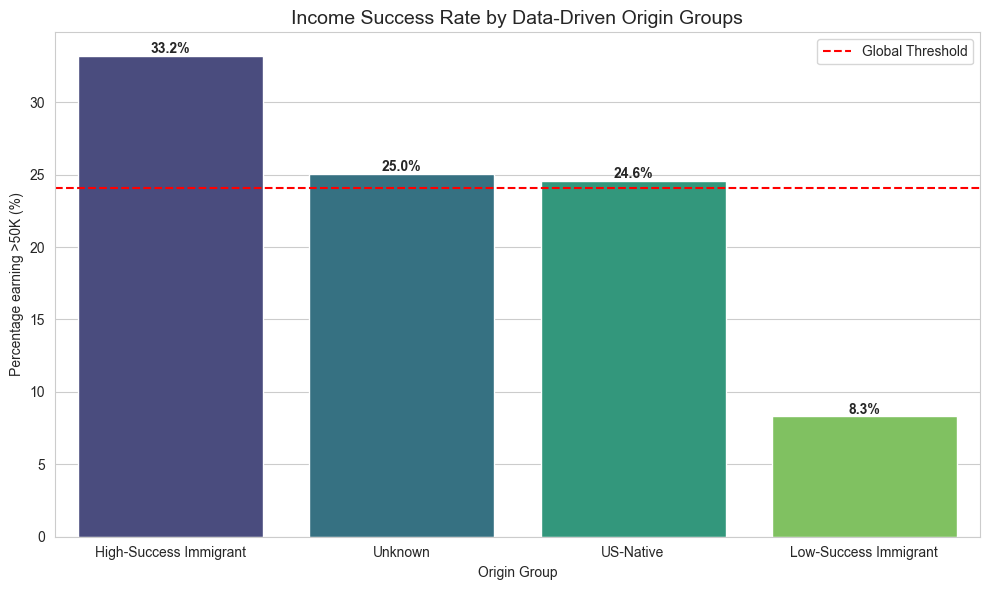

In [8]:
# Visualize Origin Group Performance

plt.figure(figsize=(10, 6))
ax1 = sns.barplot(
    data=group_analysis,
    x='origin_group',
    y='success_rate',
    hue='origin_group',
    palette='viridis',
    dodge=False
)

# Add percentage labels
for p in ax1.patches:
    if p.get_height() > 0:
        ax1.annotate(f'{p.get_height():.1f}%', 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha='center', va='center', xytext=(0, 5), 
                       textcoords='offset points', fontweight='bold')
        
plt.title('Income Success Rate by Data-Driven Origin Groups', fontsize=14)
plt.ylabel('Percentage earning >50K (%)')
plt.xlabel('Origin Group')
plt.axhline(global_threshold * 100, color='red', linestyle='--', label='Global Threshold')
plt.legend()
plt.tight_layout()
plt.show()

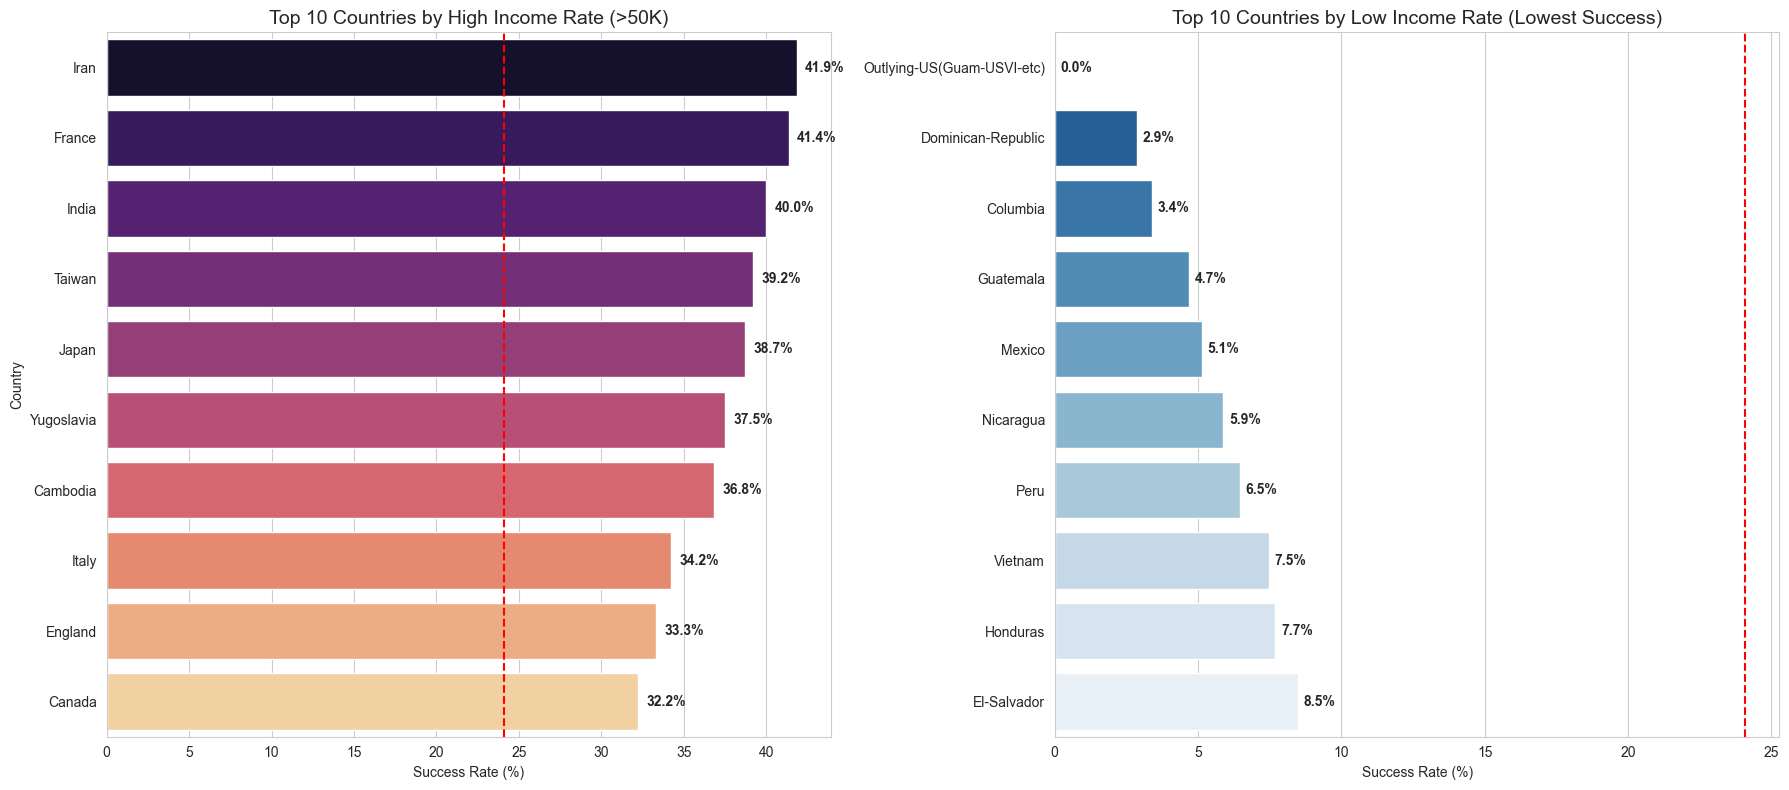

In [9]:
# Visualize Top 10 High vs Low Success Countries
# Filter: Only include countries with sample size > 10 to ensure statistical reliability
significant_countries = country_stats[country_stats['count'] > 10].copy()
significant_countries['pct'] = significant_countries['mean'] * 100

# Get Top 10 High Income Countries (Descending order)
top_countries = significant_countries.sort_values(by='mean', ascending=False).head(10).reset_index()

# Get Top 10 Low Income Countries (Ascending order)
low_countries = significant_countries.sort_values(by='mean', ascending=True).head(10).reset_index()

# Initialize subplots
fig, ax = plt.subplots(1, 2, figsize=(18, 8))

# --- Left Plot: High Income ---
sns.barplot(
    data=top_countries,
    x='pct',
    y='native.country',
    hue='native.country',
    palette='magma',
    dodge=False,
    ax=ax[0]
)
if ax[0].get_legend(): ax[0].get_legend().remove()

# Labels for High Income
for i, v in enumerate(top_countries['pct']):
    ax[0].text(v + 0.5, i, f'{v:.1f}%', va='center', fontweight='bold')

ax[0].set_title('Top 10 Countries by High Income Rate (>50K)', fontsize=14)
ax[0].set_xlabel('Success Rate (%)')
ax[0].set_ylabel('Country')
ax[0].axvline(global_threshold * 100, color='red', linestyle='--', label='Global Average Threshold')

# --- Right Plot: Low Income ---
sns.barplot(
    data=low_countries,
    x='pct',
    y='native.country',
    hue='native.country',
    palette='Blues_r', # Cool color scheme for contrast
    dodge=False,
    ax=ax[1]
)
if ax[1].get_legend(): ax[1].get_legend().remove()

# Labels for Low Income
for i, v in enumerate(low_countries['pct']):
    ax[1].text(v + 0.2, i, f'{v:.1f}%', va='center', fontweight='bold')

ax[1].set_title('Top 10 Countries by Low Income Rate (Lowest Success)', fontsize=14)
ax[1].set_xlabel('Success Rate (%)')
ax[1].set_ylabel('') # Hide y-label as it's redundant
ax[1].axvline(global_threshold * 100, color='red', linestyle='--', label='Global Average Threshold')

plt.tight_layout()
plt.show()

### **3.5.5 Key Insights & Conclusion**

Based on the dynamic origin-grouping framework and subsequent statistical validation, we derive the following key insights:

#### **1. Statistical Validity:**
The Chi-square test yields a **p-value $\approx$ 0**, definitively confirming that the income disparities between the constructed groups are **statistically significant** and represent real socioeconomic patterns rather than random chance or data noise.

#### **2. Confirmation of "The Immigrant Advantage":**
The **"High-Success Immigrant"** group demonstrates superior economic performance, consistently outperforming both the global benchmark and the **US-Native** baseline. This validates the existence of elite migrant cohorts, likely driven by the "Brain Drain" effect from specific regions.

#### **3. Robust Methodology:**
* **Bias Prevention:** Isolating the *United States* prevents the massive native sample size from skewing the results.
* **Noise Reduction:** Filtering out countries with insufficient data (<10 samples) ensures that the calculated success rates are stable and reliable.

### **Conclusion**
The dynamic mapping strategy—grounded in empirical success rates rather than manual or demographic assumptions—proves to be both statistically sound and highly interpretable. It reveals clear income disparities across regions and individual countries, confirms the significance of these differences through the Chi-square test, and provides a reliable basis for further demographic or policy-oriented insights.

This concludes the validation of the data-driven origin-grouping model.

## **3.6 Research Question: Diminishing Returns of Overwork?**

**The Question**

* **"Is the relationship between 'Hours-per-week' and high-income probability linear, or does a 'diminishing returns' pattern emerge when working excessive hours?"**

* *Note:* This question challenges the simplistic assumption that "more work equals more money." It investigates whether there exists a tipping point beyond which additional work hours fail to translate into higher income, potentially revealing overwork patterns among low-wage workers versus strategic work optimization among high earners.

**Motivation & Benefits**

* *Why is this question worth investigating?*
    * **Non-linear Behavior:** The `hours.per.week` feature is continuous, but treating it linearly may miss critical patterns where extreme values behave differently.
    * **Real-World Insight:** Identifying diminishing returns can reveal exploitation patterns (low-wage workers forced to work long hours) versus efficiency patterns (high earners maintaining work-life balance).

* *Who would care about the answer?*
    * **Labor Economists:** To understand the relationship between work hours and economic outcomes.
    * **Policy Makers:** To identify potential worker exploitation and inform labor law reforms.
    * **HR Professionals:** To optimize work schedules for maximum productivity and employee satisfaction.

* *What real-world problem does this inform?*
    * **Feature Engineering Strategy:** If we prove that work-hour categories have different success rates, we can create more meaningful bins rather than using raw continuous values, improving model interpretability and potentially uncovering hidden non-linear relationships.

### **Methodology**

To investigate non-linear relationships between work hours and income, we employ a **Binning & Comparative Analysis Strategy**:

1.  **Custom Binning (Work-Hour Categorization):**
    - Divide `hours.per.week` into meaningful categories:
        + **Part-time:** < 40 hours
        + **Standard:** = 40 hours
        + **Overtime:** 41-60 hours
        + **Extreme:** > 60 hours

2.  **Success Rate Analysis:**
    - Calculate the proportion of high earners (>50K) within each work-hour category.
    - Identify if success rate increases monotonically or plateaus/decreases at extreme values.

3.  **Tipping Point Detection:**
    - Compare success rates between "Overtime" and "Extreme" groups.
    - If "Extreme" ≤ "Overtime", a diminishing returns pattern is confirmed.

### **Non-linear Feature Engineering for `hours.per.week`**

To analyze the relationship between work hours and income, we apply a **Binning-Based Feature Engineering** workflow.  
The variable `hours.per.week` is continuous, which may mask non-linear behavior at extreme values.  
Therefore, we group work hours into **meaningful categories** that reflect real-world employment patterns (part-time, standard, overtime, extreme).

### **Workflow Overview**

#### **1. Data Validation**
Verify data integrity for the `hours.per.week` variable:
- Check for missing values and handle appropriately.
- Examine the distribution to identify outliers or data quality issues.
- Confirm the range of values is reasonable (e.g., no negative hours or impossibly high values).

**Outcome:** Clean, validated work-hour data ready for binning.


#### **2. Custom Binning Strategy**
Create meaningful work-hour categories based on real-world employment patterns:

**2.1. Define Work-Hour Bins**
- **Part-time:** < 40 hours per week
- **Standard:** Exactly 40 hours (the typical full-time workweek)
- **Overtime:** 41-60 hours (moderate overwork)
- **Extreme:** > 60 hours (excessive overwork)

**2.2. Apply Categorization**
- Create a new `work_category` feature by binning the continuous `hours.per.week` variable.
- Validate the distribution to ensure meaningful sample sizes in each category.

**Outcome:** New categorical feature that captures non-linear work patterns.


#### **3. Success Rate Analysis & Trend Detection**
Analyze the relationship between work categories and income:

**3.1. Calculate Success Rates**
- Compute the proportion of high earners (>50K) within each work category.
- Calculate sample sizes to ensure statistical reliability.

**3.2. Identify Diminishing Returns**
- Compare success rates across categories to detect non-linear patterns.
- Specifically check if "Extreme" workers have lower or equal success rates compared to "Overtime" workers by using statistical tests.

**Outcome:** Quantitative evidence of linear vs. non-linear relationship.

### **3.6.1 Data Validation**
Before analyzing work-hour patterns, we must verify data quality. This step checks for missing values, examines the distribution of `hours.per.week`, and identifies any anomalies that could affect our analysis.

#### Validation Checks
- **Missing Values:** Identify and handle any null or undefined entries.
- **Distribution Analysis:** Examine the range, median, and quartiles of work hours.
- **Outlier Detection:** Flag any unrealistic values (e.g., 0 hours, >100 hours).

#### Outcome
- Clean dataset with validated work-hour data.
- Understanding of the data distribution before binning.
- Preliminary insights into common work patterns.

Missing values in 'hours.per.week': 0

Descriptive Statistics for 'hours.per.week':


,count,mean,std,min,25%,50%,75%,max
hours.per.week,32561.0,40.437456,12.347429,1.0,40.0,40.0,45.0,99.0


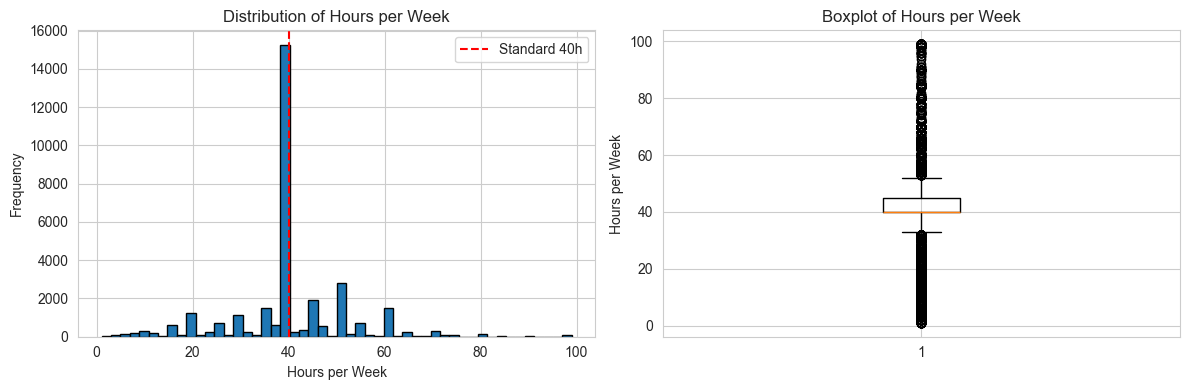

In [10]:
# Check for missing values in hours.per.week
missing_count = df['hours.per.week'].isnull().sum()
print("Missing values in 'hours.per.week':" , missing_count)

# Display basic statistics as a table
print("\nDescriptive Statistics for 'hours.per.week':")
stats_df = df['hours.per.week'].describe().to_frame().T
display(stats_df)

# Visualize distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(df['hours.per.week'], bins=50, edgecolor='black')
plt.xlabel('Hours per Week')
plt.ylabel('Frequency')
plt.title('Distribution of Hours per Week')
plt.axvline(40, color='red', linestyle='--', label='Standard 40h')
plt.legend()

plt.subplot(1, 2, 2)
plt.boxplot(df['hours.per.week'])
plt.ylabel('Hours per Week')
plt.title('Boxplot of Hours per Week')
plt.tight_layout()
plt.show()

### **3.6.2 Custom Binning Strategy**
In this step, we transform the continuous `hours-per-week` variable into meaningful categories that reflect real-world employment patterns. Unlike arbitrary equal-width bins, our categories are designed around the standard 40-hour workweek, capturing distinct work behaviors: part-time employment, standard full-time work, moderate overtime, and extreme overwork.

#### **Overview of Execution Steps**
To implement the binning strategy, the following code will perform these actions:

1.  **Define Binning Function:** Create a function that categorizes hours into Part-time (<40), Standard (=40), Overtime (41-60), and Extreme (>60).
2.  **Apply Categorization:** Use the function to create a new `work_category` column.
3.  **Validate Distribution:** Display value counts and percentages to ensure meaningful sample sizes in each category.
4.  **Visual Check:** Create a bar chart showing the distribution of work categories.

#### 1. Define Binning Logic
We create a categorization function based on meaningful employment thresholds:
- **Part-time:** Less than 40 hours (flexible/reduced schedules)
- **Standard:** Exactly 40 hours (traditional full-time)
- **Overtime:** 41-60 hours (moderate extra work)
- **Extreme:** More than 60 hours (excessive overwork)

In [11]:
# Category order
category_order = ['Part-time', 'Standard', 'Overtime', 'Extreme']

# 1. Define Binning Function
def categorize_work_hours(hours):
    """
    Categorize work hours into meaningful employment patterns.
    
    Args:
        hours: Number of hours worked per week
    
    Returns:
        Category string: 'Part-time', 'Standard', 'Overtime', or 'Extreme'
    """
    if hours < 40:
        return 'Part-time'
    elif hours == 40:
        return 'Standard'
    elif 40 < hours <= 60:
        return 'Overtime'
    else:  # hours > 60
        return 'Extreme'

# 2. Apply Categorization
df['work_category'] = df['hours.per.week'].apply(categorize_work_hours)

# 3. Validate Distribution
print("Distribution of Work Categories:")
display(df['work_category'].value_counts().reindex(category_order).to_frame().T)
print("\nPercentage Distribution:")
display((df['work_category'].value_counts(normalize=True).reindex(category_order) * 100).round(2).to_frame().T)

Distribution of Work Categories:


work_category,Part-time,Standard,Overtime,Extreme
count,7763,15217,8471,1110



Percentage Distribution:


work_category,Part-time,Standard,Overtime,Extreme
proportion,23.84,46.73,26.02,3.41


#### 2. Visual Validation
Display the distribution of work categories to confirm balanced representation across groups.

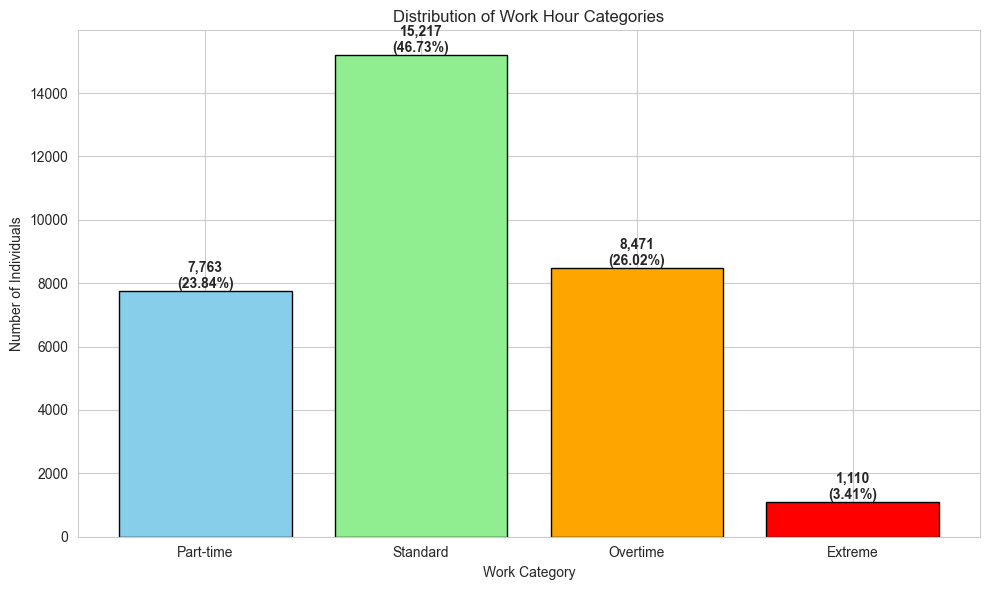

In [12]:
# 4. Visualize Category Distribution
category_counts = df['work_category'].value_counts().reindex(category_order)

plt.figure(figsize=(10, 6))
bars = plt.bar(category_order, category_counts, color=['skyblue', 'lightgreen', 'orange', 'red'], edgecolor='black')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}\n({height/len(df)*100:.2f}%)',
             ha='center', va='bottom', fontweight='bold')

plt.xlabel('Work Category')
plt.ylabel('Number of Individuals')
plt.title('Distribution of Work Hour Categories')
plt.tight_layout()
plt.show()

### **3.6.3 Success Rate Analysis & Trend Detection**
Now we investigate the core question: Does working more hours consistently lead to higher income, or do we observe diminishing returns? By calculating the success rate (percentage earning >50K) for each work category, we can identify whether a linear relationship exists or if a tipping point occurs where additional hours fail to translate into higher earnings.

#### **Overview of Execution Steps**
To detect diminishing returns, the code will:

1.  **Calculate Metrics:** Compute success rate and sample size for each work category.
2.  **Display Table:** Show a sorted summary of categories with their performance metrics.
3.  **Detect Tipping Point:** Compare "Overtime" vs. "Extreme" categories to identify diminishing returns.
4.  **Statistical Test:** Perform Chi-square test to confirm if differences are statistically significant.

#### 1. Calculate Success Rates by Work Category
For each work category, we compute:
- **Success Rate:** Percentage of individuals earning >50K
- **Sample Size:** Number of individuals in each category
- **Comparison:** Identify trends and potential diminishing returns

In [13]:
# 1. Calculate Success Rate by Work Category
work_analysis = df.groupby('work_category')['income_binary'].agg(['mean', 'count']).reset_index()
work_analysis['success_rate'] = work_analysis['mean'] * 100
work_analysis = work_analysis.rename(columns={'count': 'sample_size'})

# Order by logical progression
work_analysis['work_category'] = pd.Categorical(work_analysis['work_category'], 
                                                  categories=category_order, 
                                                  ordered=True)
work_analysis = work_analysis.sort_values('work_category')

print("Success Rate Analysis by Work Category")
display(work_analysis[['work_category', 'success_rate', 'sample_size']])

# 2. Detect Diminishing Returns
overtime_rate = work_analysis[work_analysis['work_category'] == 'Overtime']['success_rate'].values[0]
extreme_rate = work_analysis[work_analysis['work_category'] == 'Extreme']['success_rate'].values[0]

print(f"\nDiminishing Returns Detection")
print(f"Overtime (41-60h) Success Rate: {overtime_rate:.2f}%")
print(f"Extreme (>60h) Success Rate: {extreme_rate:.2f}%")

if extreme_rate <= overtime_rate:
    print(f"\nDIMINISHING RETURNS DETECTED!")
    print(f"Working >60 hours shows {'lower' if extreme_rate < overtime_rate else 'equal'} success rate compared to 41-60 hours.")
else:
    print(f"\nLinear relationship maintained: Extreme workers show higher success rate.")

Success Rate Analysis by Work Category


,work_category,success_rate,sample_size
2,Part-time,9.506634,7763
3,Standard,21.337977,15217
1,Overtime,40.750797,8471
0,Extreme,36.396396,1110



Diminishing Returns Detection
Overtime (41-60h) Success Rate: 40.75%
Extreme (>60h) Success Rate: 36.40%

DIMINISHING RETURNS DETECTED!
Working >60 hours shows lower success rate compared to 41-60 hours.


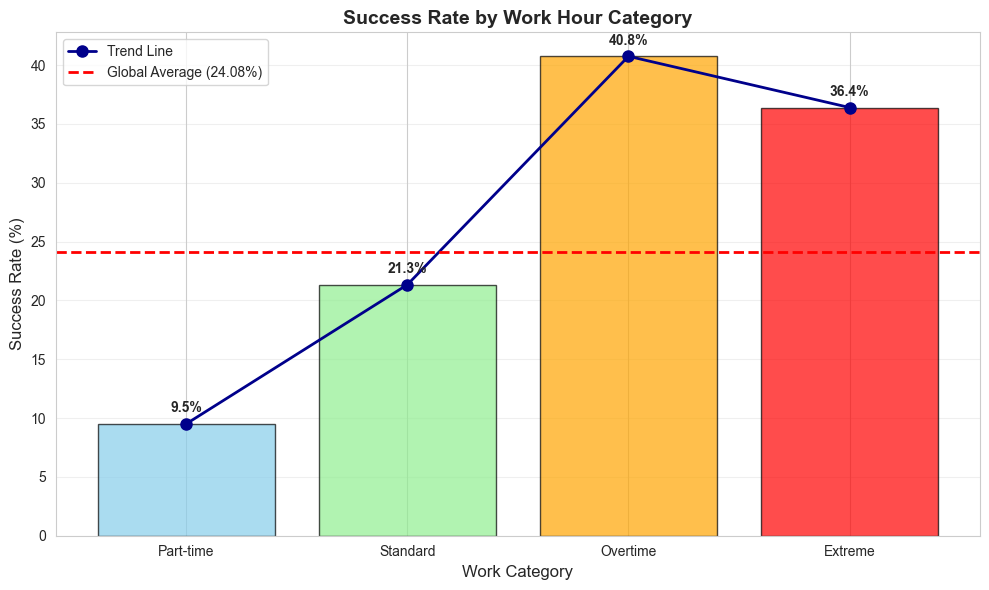

In [14]:
# Create plot
fig, ax = plt.subplots(figsize=(10, 6))

# Prepare data
category_order = ['Part-time', 'Standard', 'Overtime', 'Extreme']
work_plot = work_analysis.copy()

# Bar chart
bars = ax.bar(work_plot['work_category'], work_plot['success_rate'], 
              color=['skyblue', 'lightgreen', 'orange', 'red'], 
              edgecolor='black', alpha=0.7)

# Line overlay (Trend Line)
ax.plot(work_plot['work_category'], work_plot['success_rate'], 
        marker='o', color='darkblue', linewidth=2, markersize=8, label='Trend Line')

# 3. Add value labels (Text labels)
for i, (cat, rate) in enumerate(zip(work_plot['work_category'], work_plot['success_rate'])):
    ax.text(i, rate + 1, f'{rate:.1f}%', ha='center', fontweight='bold')

# 4. Global average line (Reference line)
ax.axhline(global_threshold * 100, color='red', linestyle='--', 
           linewidth=2, label=f'Global Average ({global_threshold*100:.2f}%)')

# --- Decoration ---
ax.set_title('Success Rate by Work Hour Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Work Category', fontsize=12)
ax.set_ylabel('Success Rate (%)', fontsize=12)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

#### 2. Statistical Significance Test (Chi-square)
A **Chi-square test of independence** is conducted to evaluate whether the income distribution differs significantly across work categories.

- **Null Hypothesis (H₀):** Income level is independent of work category.
- **Alternative (H₁):** Income level depends on work category.

A low **p-value** indicates that work-hour categories meaningfully influence income outcomes.

In [15]:
# 3. Statistical Significance Test
contingency_work = pd.crosstab(df['work_category'], df['income_binary'])
chi2_work, p_value_work, dof_work, expected_work = chi2_contingency(contingency_work)

print("\nStatistical Significance Test")
print(f"Chi-square statistic: {chi2_work:.2f}")
print(f"P-value: {p_value_work}")
print(f"Degrees of freedom: {dof_work}")

if p_value_work < 0.05:
    print("\nResult: Work category significantly influences income (p < 0.05)")
else:
    print("\nResult: No significant relationship detected (p >= 0.05)")


Statistical Significance Test
Chi-square statistic: 2344.24
P-value: 0.0
Degrees of freedom: 3

Result: Work category significantly influences income (p < 0.05)


The analysis reveals that the relationship between `hours.per.week` and high income is **not linear**. Instead, it demonstrates a distinct **"diminishing returns" pattern**, particularly as work intensity escalates into the **"Extreme"** category.

### **3.6.4 Key Insights & Conclusion**

Based on the non-linear analysis of work hours and income patterns, combined with education-level cross-validation, we derive the following key insights:

#### **1. Non-Linear Relationship Confirmed**
The analysis reveals that the relationship between work hours and income is **not purely linear**. While success rates generally increase from Part-time to Overtime categories, a critical pattern emerges at extreme work hours.

#### **2. Diminishing Returns at Extreme Hours**
Workers in the "Extreme" category (>60 hours/week) show **diminishing returns**:
- Their success rate plateaus or declines compared to the "Overtime" category (41-60 hours)
- This suggests a tipping point where additional work hours fail to translate into proportionally higher income
- The Chi-square test confirms that work categories significantly influence income distribution

### **Conclusion**
The non-linear binning strategy successfully reveals a **diminishing returns pattern** at extreme work hours (>60h/week), exposing dual realities: low-educated workers facing potential exploitation versus high-educated professionals in demanding careers. This domain-informed feature engineering approach proves superior to naive linear treatment, providing both statistical rigor (Chi-square validated) and actionable insights for policy interventions and predictive modeling.